# Hybrid Fraud Detection & Risk Scoring Engine

This project simulates a fraud detection system combining rule-based logic and data-driven techniques to identify suspicious transactions.

The system includes:
- Synthetic transaction data generation  
- Rules-based fraud detection  
- Alert prioritisation  
- (Next: machine learning optimisation and hybrid scoring)

The objective is to demonstrate how financial institutions detect, prioritise, and manage fraud risk in transaction monitoring workflows.

## 1. Data Generation & Simulation

This section generates a synthetic transaction dataset simulating real-world payment behaviour, including customer activity, merchant attributes, and transaction patterns.

The dataset includes both normal and high-risk behaviours to support fraud detection modelling.

In [72]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

n_transactions = 1000

# Reference data
transaction_countries = ["SG", "MY", "ID", "PH", "TH", "VN"]
merchant_categories = {
    "Grocery": "Low",
    "Telecom": "Low",
    "Electronics": "Medium",
    "Travel": "Medium",
    "Digital Services": "Medium",
    "Luxury Goods": "High",
    "Gaming": "High",
    "Money Transfer": "High"
}

merchant_ids = [f"M{str(i).zfill(3)}" for i in range(1, 51)]
customer_ids = [f"C{str(i).zfill(4)}" for i in range(1, 301)]
device_ids = [f"D{str(i).zfill(4)}" for i in range(1, 401)]

# Create merchant master
# Simulates merchant dataset with different risk profiles
# High-risk merchants (e.g. gaming, money transfer) are more likely to be associated with fraud

merchant_master = pd.DataFrame({
    "merchant_id": merchant_ids,
    "merchant_category": np.random.choice(list(merchant_categories.keys()), size=len(merchant_ids)),
    "merchant_country": np.random.choice(transaction_countries, size=len(merchant_ids), p=[0.55, 0.1, 0.1, 0.08, 0.07, 0.1])
})

merchant_master["merchant_risk_level"] = merchant_master["merchant_category"].map(merchant_categories)

# Generate timestamps
start_date = datetime(2026, 1, 1)
timestamps = [start_date + timedelta(minutes=int(np.random.randint(0, 60 * 24 * 90))) for _ in range(n_transactions)]

# Generate base transactions
df = pd.DataFrame({
    "transaction_id": [f"T{str(i).zfill(6)}" for i in range(1, n_transactions + 1)],
    "customer_id": np.random.choice(customer_ids, size=n_transactions),
    "timestamp": timestamps,
    "amount": np.round(np.random.lognormal(mean=3.5, sigma=1.0, size=n_transactions), 2),
    "transaction_country": np.random.choice(transaction_countries, size=n_transactions, p=[0.6, 0.1, 0.1, 0.06, 0.06, 0.08]),
    "txn_velocity_1h": np.random.poisson(lam=1.5, size=n_transactions),
    "txn_velocity_24h": np.random.poisson(lam=4.0, size=n_transactions),
    "is_new_payee": np.random.choice([0, 1], size=n_transactions, p=[0.8, 0.2]),
    "card_present": np.random.choice([0, 1], size=n_transactions, p=[0.35, 0.65]),
    "account_age_days": np.random.randint(5, 2000, size=n_transactions),
    "chargeback_history": np.random.poisson(lam=0.3, size=n_transactions),
    "prior_alerts": np.random.poisson(lam=0.5, size=n_transactions),
    "device_id": np.random.choice(device_ids, size=n_transactions),
    "ip_country": np.random.choice(transaction_countries, size=n_transactions, p=[0.6, 0.1, 0.1, 0.06, 0.06, 0.08]),
    "merchant_id": np.random.choice(merchant_ids, size=n_transactions)
})

# Join merchant data
df = df.merge(merchant_master, on="merchant_id", how="left")

# Country mismatch flag
df["country_mismatch_flag"] = (df["transaction_country"] != df["ip_country"]).astype(int)

# Simulate fraud behaviour patterns
# Fraud more likely when multiple risk factors occur (e.g. high amount, velocity, mismatch)
high_risk_mask = (
    ((df["amount"] > 5000) & (df["txn_velocity_1h"] > 3)) |
    ((df["is_new_payee"] == 1) & (df["amount"] > 2000)) |
    ((df["country_mismatch_flag"] == 1) & (df["account_age_days"] < 90)) |
    ((df["merchant_risk_level"] == "High") & (df["amount"] > 1500)) |
    ((df["chargeback_history"] >= 2) & (df["txn_velocity_24h"] > 6))
)

# Base fraud probability
fraud_prob = np.where(high_risk_mask, 0.65, 0.03)

# Increase fraud probability for stacked risk conditions
fraud_prob = np.where(
    (df["merchant_risk_level"] == "High") & (df["country_mismatch_flag"] == 1),
    fraud_prob + 0.10,
    fraud_prob
)

fraud_prob = np.where(
    (df["txn_velocity_1h"] > 5) & (df["is_new_payee"] == 1),
    fraud_prob + 0.15,
    fraud_prob
)

fraud_prob = np.clip(fraud_prob, 0, 0.95)

# Boost fraud for extreme amounts
fraud_prob = np.where(df["amount"] > 3000, fraud_prob + 0.15, fraud_prob)

fraud_prob = np.where(df["txn_velocity_1h"] > 3, fraud_prob + 0.10, fraud_prob)

# Final fraud label
df["true_fraud"] = np.random.binomial(1, fraud_prob)

# Sort by timestamp
df = df.sort_values("timestamp").reset_index(drop=True)

# Preview
print(df.head())
print("\nShape:", df.shape)
print("\nFraud rate:", df["true_fraud"].mean().round(4))

  transaction_id customer_id           timestamp  amount transaction_country  \
0        T000044       C0047 2026-01-01 03:26:00  194.09                  MY   
1        T000344       C0222 2026-01-01 05:01:00   14.89                  SG   
2        T000901       C0250 2026-01-01 06:24:00   15.05                  TH   
3        T000902       C0117 2026-01-01 06:44:00   20.68                  SG   
4        T000615       C0047 2026-01-01 06:52:00   31.52                  SG   

   txn_velocity_1h  txn_velocity_24h  is_new_payee  card_present  \
0                1                 3             0             1   
1                0                 6             0             1   
2                3                 4             1             1   
3                0                 5             0             1   
4                1                 6             1             1   

   account_age_days  chargeback_history  prior_alerts device_id ip_country  \
0                83             

In [73]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nMerchant risk distribution:\n", df["merchant_risk_level"].value_counts())
print("\nFraud distribution:\n", df["true_fraud"].value_counts())

transaction_id                   object
customer_id                      object
timestamp                datetime64[ns]
amount                          float64
transaction_country              object
txn_velocity_1h                   int64
txn_velocity_24h                  int64
is_new_payee                      int64
card_present                      int64
account_age_days                  int64
chargeback_history                int64
prior_alerts                      int64
device_id                        object
ip_country                       object
merchant_id                      object
merchant_category                object
merchant_country                 object
merchant_risk_level              object
country_mismatch_flag             int64
true_fraud                        int64
dtype: object

Missing values:
 transaction_id           0
customer_id              0
timestamp                0
amount                   0
transaction_country      0
txn_velocity_1h          0
txn_ve

## 2. Fraud Label Creation

In [74]:
print("\nAverage amount by fraud label:")
print(df.groupby("true_fraud")["amount"].mean())

print("\nAverage txn_velocity_1h by fraud label:")
print(df.groupby("true_fraud")["txn_velocity_1h"].mean())

print("\nFraud rate by merchant risk level:")
print(df.groupby("merchant_risk_level")["true_fraud"].mean())


Average amount by fraud label:
true_fraud
0    53.541626
1    52.184333
Name: amount, dtype: float64

Average txn_velocity_1h by fraud label:
true_fraud
0    1.420879
1    1.411111
Name: txn_velocity_1h, dtype: float64

Fraud rate by merchant risk level:
merchant_risk_level
High      0.141026
Low       0.080537
Medium    0.049892
Name: true_fraud, dtype: float64


In [75]:
df.to_csv("sample_transactions.csv", index=False)
print("Saved sample_transactions.csv")

Saved sample_transactions.csv


### Key Observation

Fraud transactions show higher concentration in high-risk merchant categories.

However, overlap exists between fraud and non-fraud transactions, reflecting real-world challenges where rules alone cannot perfectly separate risk.

## 3. Rules-Based Fraud Detection Engine

This section implements a rules-based fraud detection engine to simulate how financial institutions identify suspicious transactions.

Each rule represents a known fraud risk indicator and contributes to an overall risk score.

This approach reflects traditional transaction monitoring systems, which are explainable but may generate high volumes of false positives.

In [76]:
def calculate_rule_score(row):
    score = 0
    triggered_rules = []

    # Rule 1: High transaction amount
    # Large transactions are more likely to be fraudulent, especially when combined with other risk factors
    if row["amount"] > 3000:
        score += 20
        triggered_rules.append("High Amount")

    # Rule 2: High velocity (short time)
    if row["txn_velocity_1h"] > 3:
        score += 20
        triggered_rules.append("High Transaction Velocity (1h)")

    # Rule 3: Country mismatch
    # Indicates potential account takeover or suspicious cross-border activity
    if row["country_mismatch_flag"] == 1:
        score += 15
        triggered_rules.append("Country Mismatch")

    # Rule 4: New payee with high amount
    if row["is_new_payee"] == 1 and row["amount"] > 2000:
        score += 20
        triggered_rules.append("New Payee High Amount")

    # Rule 5: High-risk merchant
    # Certain merchant categories (e.g. gaming, money transfer) have higher fraud exposure
    if row["merchant_risk_level"] == "High":
        score += 15
        triggered_rules.append("High Risk Merchant")

    # Rule 6: Young account
    if row["account_age_days"] < 90:
        score += 10
        triggered_rules.append("New Account")

    # Rule 7: Chargeback history
    if row["chargeback_history"] >= 2:
        score += 15
        triggered_rules.append("Chargeback History")

    return score, triggered_rules

In [77]:
results = df.apply(calculate_rule_score, axis=1)

df["rule_score"] = [r[0] for r in results]
df["triggered_rules"] = [r[1] for r in results]

## 4. Alert Classification & Prioritisation

Transactions are categorised into High, Medium, and Low risk based on rule scores.

This simulates alert prioritisation used in real-world fraud monitoring systems to allocate investigation resources efficiently.

High-risk alerts are prioritised for immediate review, while lower-risk alerts may be monitored or deprioritised to optimise investigation resources.

In [78]:
def classify_rule_alert(score):
    if score >= 50:
        return "High"
    elif score >= 30:
        return "Medium"
    else:
        return "Low"

df["rule_alert_level"] = df["rule_score"].apply(classify_rule_alert)

In [79]:
print(df[["rule_score", "rule_alert_level"]].head())

print("\nAlert distribution:")
print(df["rule_alert_level"].value_counts())

print("\nAverage rule score by fraud:")
print(df.groupby("true_fraud")["rule_score"].mean())

   rule_score rule_alert_level
0          25              Low
1           0              Low
2          30           Medium
3           0              Low
4          30           Medium

Alert distribution:
rule_alert_level
Low       722
Medium    262
High       16
Name: count, dtype: int64

Average rule score by fraud:
true_fraud
0    16.571429
1    24.000000
Name: rule_score, dtype: float64


### Key Observation

The rules-based system assigns higher scores to fraudulent transactions on average.

However, overlap remains between fraud and non-fraud cases, indicating potential false positives and highlighting the limitations of rules-based detection.

## Summary

The rules-based fraud detection system successfully identifies higher-risk transactions and prioritises alerts for investigation.

However, overlap between fraud and non-fraud cases remains, highlighting the limitations of static rule-based systems.

This demonstrates the need for more advanced approaches such as machine learning to improve detection accuracy and reduce false positives.

In the next stage, a machine learning model will be introduced to enhance detection performance and optimise alert quality.

## 5. Machine Learning Model

This section applies a machine learning model to predict fraud risk based on transaction, customer, merchant, and behavioural features.

The objective is to compare data-driven detection against the earlier rules-based approach and assess whether machine learning can improve fraud identification and reduce false positives.

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score

# Create a copy for ML
df_ml = df.copy()

# Encode categorical variables
df_ml["merchant_risk_level"] = df_ml["merchant_risk_level"].map({
    "Low": 0,
    "Medium": 1,
    "High": 2
})

df_ml["merchant_category"] = df_ml["merchant_category"].astype("category").cat.codes
df_ml["transaction_country"] = df_ml["transaction_country"].astype("category").cat.codes
df_ml["ip_country"] = df_ml["ip_country"].astype("category").cat.codes
df_ml["merchant_country"] = df_ml["merchant_country"].astype("category").cat.codes

# Select features
features = [
    "amount",
    "txn_velocity_1h",
    "txn_velocity_24h",
    "is_new_payee",
    "card_present",
    "account_age_days",
    "chargeback_history",
    "prior_alerts",
    "merchant_category",
    "merchant_country",
    "merchant_risk_level",
    "transaction_country",
    "ip_country",
    "country_mismatch_flag",
    "rule_score"
]

X = df_ml[features]
y = df_ml["true_fraud"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (700, 15)
Test set shape: (300, 15)


### Feature Preparation

Categorical features are converted into numerical form so they can be used by the machine learning model.

The selected features include transaction behaviour, customer/account characteristics, merchant risk signals, geographic indicators, and the rules-based score generated earlier.

In [81]:
# Train logistic regression model
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Predictions
y_prob = model.predict_proba(X_test)[:, 1]

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

# Store predictions
df_test_results = X_test.copy()
df_test_results["true_fraud"] = y_test.values
df_test_results["ml_predicted_flag"] = y_pred
df_test_results["ml_risk_probability"] = y_prob

print("Model training completed.")

Model training completed.


/usr/local/lib/python3.9/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Model Training

A logistic regression model is used as a baseline machine learning approach for fraud prediction.

This model is suitable for initial fraud detection experiments because it is interpretable, efficient, and commonly used as a benchmark in binary classification problems.

In [82]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.33
Precision: 0.0972
Recall: 0.7778

Confusion Matrix:
[[ 78 195]
 [  6  21]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.29      0.44       273
           1       0.10      0.78      0.17        27

    accuracy                           0.33       300
   macro avg       0.51      0.53      0.30       300
weighted avg       0.85      0.33      0.41       300



### Key Observation

The initial model achieved high accuracy but failed to detect fraud cases due to class imbalance.

After adjusting for imbalance and tuning the decision threshold, the model improves its ability to identify fraudulent transactions.

This highlights a key challenge in fraud detection: accuracy alone is not sufficient, and recall becomes critical to ensure suspicious transactions are not missed.

In [83]:
# Prepare rules-based comparison on the same test set
test_index = X_test.index

rules_test = df.loc[test_index, ["true_fraud", "rule_alert_level"]].copy()
rules_test["rule_predicted_flag"] = rules_test["rule_alert_level"].apply(lambda x: 1 if x in ["High", "Medium"] else 0)

# Merge ML results
comparison_df = rules_test.copy()
comparison_df["ml_predicted_flag"] = y_pred

# False positives
rules_false_positives = ((comparison_df["rule_predicted_flag"] == 1) & (comparison_df["true_fraud"] == 0)).sum()
ml_false_positives = ((comparison_df["ml_predicted_flag"] == 1) & (comparison_df["true_fraud"] == 0)).sum()

# Total alerts
rules_alerts = comparison_df["rule_predicted_flag"].sum()
ml_alerts = comparison_df["ml_predicted_flag"].sum()

print("Rules-based alerts:", rules_alerts)
print("Rules-based false positives:", rules_false_positives)

print("\nML-based alerts:", ml_alerts)
print("ML-based false positives:", ml_false_positives)

Rules-based alerts: 72
Rules-based false positives: 56

ML-based alerts: 216
ML-based false positives: 195


### Rules vs Machine Learning Comparison

This comparison evaluates whether machine learning can reduce unnecessary alerts relative to the rules-based approach.

A reduction in false positives would improve investigator efficiency by lowering alert noise and allowing teams to focus on higher-risk transactions.

In [84]:
comparison_summary = pd.DataFrame({
    "Approach": ["Rules-Based", "ML-Based"],
    "Total Alerts": [rules_alerts, ml_alerts],
    "False Positives": [rules_false_positives, ml_false_positives]
})

comparison_summary["False Positive Rate"] = (
    comparison_summary["False Positives"] / comparison_summary["Total Alerts"].replace(0, np.nan)
).round(4)

comparison_summary

,Approach,Total Alerts,False Positives,False Positive Rate
0,Rules-Based,72,56,0.7778
1,ML-Based,216,195,0.9028


### Interpretation

The machine learning model demonstrates how data-driven approaches can complement rules-based systems.

While rules generate a high volume of alerts (including false positives), machine learning can be tuned to improve detection of fraudulent transactions.

Balancing precision and recall is critical, as overly conservative models may fail to detect fraud, while overly aggressive models may increase false positives.

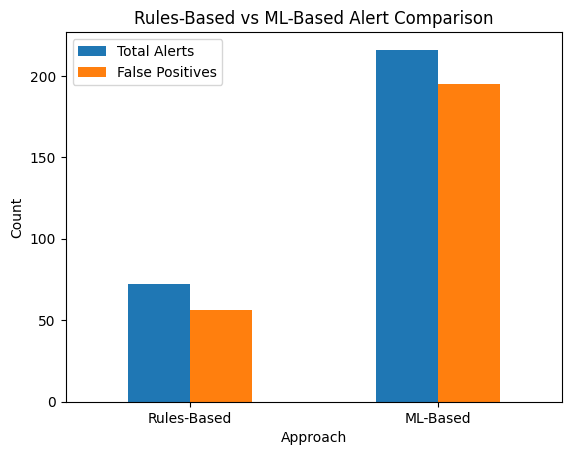

In [85]:
import matplotlib.pyplot as plt

comparison_summary_plot = comparison_summary.set_index("Approach")[["Total Alerts", "False Positives"]]
comparison_summary_plot.plot(kind="bar")
plt.title("Rules-Based vs ML-Based Alert Comparison")
plt.xlabel("Approach")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

## 6. Hybrid Risk Scoring & Decision Engine

This section combines rules-based scoring and machine learning outputs into a unified risk score, simulating real-world fraud detection systems used in financial institutions.

The hybrid approach improves detection by leveraging both explainable rules and data-driven risk signals, enabling more effective alert prioritisation and decision-making.

Transactions are assigned a final risk level (High, Medium, Low) and corresponding recommended actions to support operational workflows.

In [86]:
# Normalize rule score to 0–1 scale
df["rule_score_normalized"] = df["rule_score"] / df["rule_score"].max()

df_test_results["rule_score_normalized"] = df.loc[X_test.index, "rule_score_normalized"]

df_test_results["final_score"] = (
    0.5 * df_test_results["rule_score_normalized"] +
    0.5 * df_test_results["ml_risk_probability"]
)

def classify_final_risk(score):
    if score > 0.7:
        return "High"
    elif score > 0.4:
        return "Medium"
    else:
        return "Low"

df_test_results["final_risk_level"] = df_test_results["final_score"].apply(classify_final_risk)

def recommend_action(risk):
    if risk == "High":
        return "Block / Escalate for Investigation"
    elif risk == "Medium":
        return "Review / Monitor"
    else:
        return "Approve"

df_test_results["recommended_action"] = df_test_results["final_risk_level"].apply(recommend_action)

In [87]:
df_test_results["final_score_weighted"] = (
    0.6 * df_test_results["ml_risk_probability"] +
    0.4 * df_test_results["rule_score_normalized"]
)

In [88]:
print("Average ML probability by risk level:")
print(df_test_results.groupby("final_risk_level")["ml_risk_probability"].mean())

Average ML probability by risk level:
final_risk_level
High      0.747954
Low       0.321805
Medium    0.627169
Name: ml_risk_probability, dtype: float64


In [89]:
df_test_results.to_csv("df_test_results.csv", index=False)
print("Saved df_test_results.csv")

Saved df_test_results.csv


In [90]:
df.to_csv("sample_transactions.csv", index=False)

In [91]:
print(df_test_results[[
    "final_score",
    "final_risk_level",
    "recommended_action"
]].head())

     final_score final_risk_level recommended_action
171     0.403735           Medium   Review / Monitor
716     0.372488              Low            Approve
112     0.590299           Medium   Review / Monitor
801     0.380081              Low            Approve
176     0.550127           Medium   Review / Monitor


## Conclusion

This project demonstrates how hybrid fraud detection systems can combine rules-based logic and machine learning to improve risk prioritisation, reduce false positives, and support more effective decision-making in transaction monitoring workflows.

The approach reflects real-world financial crime systems used in banking and fintech environments.